# HW08-09 — PyTorch MLP: подготовка, данные, модель и цикл обучения

Для домашней работы по умолчанию выбран **EMNIST** 

In [2]:
!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   - -------------------------------------- 3.7/113.8 MB 14.6 MB/s eta 0:00:08
   -- ------------------------------------- 6.3/113.8 MB 13.8 MB/s eta 0:00:08
   -- ------------------------------------- 7.3/113.8 MB 12.1 MB/s eta 0:00:09
   ---- ----------------------------------- 13.1/113.8 MB 15.2 MB/s eta 0:00:07
   ------ --------------------------------- 17.8/113.8 MB 17.1 MB/s eta 0:00:06
   ------- -------------------------------- 21.8/113.8 MB 16.9 MB/s eta 0:00:06
   --------- ------------------------------ 27.0/113.8 MB 18.1 MB/s eta 0:00:05
   ---------- ----------------------------- 29.6/113.8 MB 17.4 MB/s eta 0:00:05
   ------------ --------------------------- 35.7/113.8 MB 18.6 MB/s eta 0:00:05
   ------------- -------------------------- 38.5/113.8 MB 18.3 MB/s eta 0:00:05
   --------------- ------------------------ 43.3/113.8 MB 18.

In [89]:
import os
import json
import math
import random
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

In [24]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Насколько возможно повышаем воспроизводимость.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed:", SEED)
print("Device:", device)

Seed: 42
Device: cpu


In [43]:
@dataclass
class DataConfig:
    dataset_name: str = "EMNIST"    
    data_root: str = "./data"
    batch_size: int = 128
    val_ratio: float = 0.2
    num_workers: int = 0
    pin_memory: bool = torch.cuda.is_available()


data_config = DataConfig()
data_config

DataConfig(dataset_name='EMNIST', data_root='./data', batch_size=128, val_ratio=0.2, num_workers=0, pin_memory=False)

In [44]:
def get_transforms(dataset_name: str):
    dataset_name = dataset_name.upper()

    if dataset_name in {"FASHIONMNIST", "KMNIST", "EMNIST"}:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5,), std=(0.5,))
        ])

    if dataset_name == "CIFAR10":
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
        ])

    raise ValueError(f"Неизвестный датасет: {dataset_name}")

In [45]:
def load_datasets(config: DataConfig):
    dataset_name = config.dataset_name.upper()
    transform = get_transforms(dataset_name)

    if dataset_name == "FASHIONMNIST":
        train_dataset_full = datasets.FashionMNIST(
            root=config.data_root,
            train=True,
            download=True,
            transform=transform,
        )
        test_dataset = datasets.FashionMNIST(
            root=config.data_root,
            train=False,
            download=True,
            transform=transform,
        )
        num_classes = 10
        input_shape = (1, 28, 28)

    elif dataset_name == "KMNIST":
        train_dataset_full = datasets.KMNIST(
            root=config.data_root,
            train=True,
            download=True,
            transform=transform,
        )
        test_dataset = datasets.KMNIST(
            root=config.data_root,
            train=False,
            download=True,
            transform=transform,
        )
        num_classes = 10
        input_shape = (1, 28, 28)

    elif dataset_name == "EMNIST":
        train_dataset_full = datasets.EMNIST(
            root=config.data_root,
            split="balanced",
            train=True,
            download=True,
            transform=transform,
        )
        test_dataset = datasets.EMNIST(
            root=config.data_root,
            split="balanced",
            train=False,
            download=True,
            transform=transform,
        )
        num_classes = 47
        input_shape = (1, 28, 28)

    elif dataset_name == "CIFAR10":
        train_dataset_full = datasets.CIFAR10(
            root=config.data_root,
            train=True,
            download=True,
            transform=transform,
        )
        test_dataset = datasets.CIFAR10(
            root=config.data_root,
            train=False,
            download=True,
            transform=transform,
        )
        num_classes = 10
        input_shape = (3, 32, 32)

    else:
        raise ValueError(f"Неизвестный датасет: {dataset_name}")

    return train_dataset_full, test_dataset, input_shape, num_classes

In [46]:
train_dataset_full, test_dataset, input_shape, num_classes = load_datasets(data_config)

train_size = int(len(train_dataset_full) * (1 - data_config.val_ratio))
val_size = len(train_dataset_full) - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=split_generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=data_config.batch_size,
    shuffle=True,
    num_workers=data_config.num_workers,
    pin_memory=data_config.pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=data_config.batch_size,
    shuffle=False,
    num_workers=data_config.num_workers,
    pin_memory=data_config.pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=data_config.batch_size,
    shuffle=False,
    num_workers=data_config.num_workers,
    pin_memory=data_config.pin_memory,
)

print(f"Dataset      : {data_config.dataset_name}")
print(f"Train total  : {len(train_dataset_full):,}")
print(f"Train split  : {len(train_dataset):,}")
print(f"Val split    : {len(val_dataset):,}")
print(f"Test         : {len(test_dataset):,}")
print(f"Input shape  : {input_shape}")
print(f"Num classes  : {num_classes}")

100%|██████████| 562M/562M [17:25<00:00, 538kB/s]    


Dataset      : EMNIST
Train total  : 112,800
Train split  : 90,240
Val split    : 22,560
Test         : 18,800
Input shape  : (1, 28, 28)
Num classes  : 47


### 2.1. Sanity-check

Проверим:
- размер батча;
- `shape` у `x` и `y`;
- типы данных;
- диапазон значений после `transform`;
- несколько примеров из датасета.

In [47]:
x_batch, y_batch = next(iter(train_loader))

print("x_batch.shape:", x_batch.shape)
print("y_batch.shape:", y_batch.shape)
print("x dtype      :", x_batch.dtype)
print("y dtype      :", y_batch.dtype)
print("x min/max    :", float(x_batch.min()), float(x_batch.max()))
print("labels sample:", y_batch[:10].tolist())

x_batch.shape: torch.Size([128, 1, 28, 28])
y_batch.shape: torch.Size([128])
x dtype      : torch.float32
y dtype      : torch.int64
x min/max    : -1.0 1.0
labels sample: [0, 6, 38, 43, 21, 16, 30, 17, 1, 44]


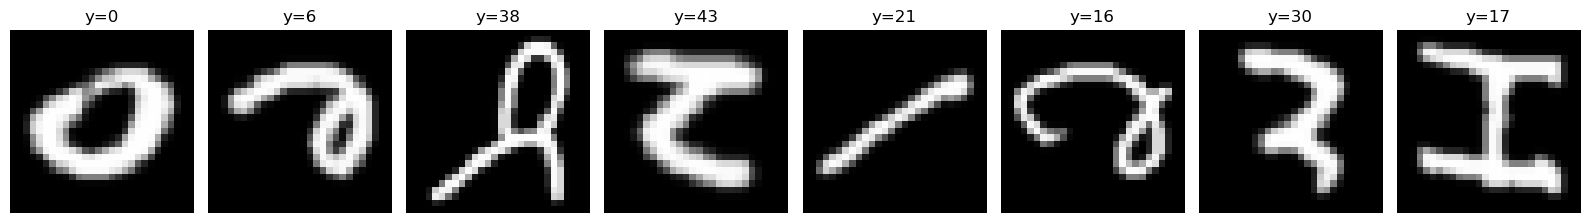

In [48]:
def show_batch(images: torch.Tensor, labels: torch.Tensor, n: int = 8):
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))

    if n == 1:
        axes = [axes]

    for i in range(n):
        img = images[i].detach().cpu()
        if img.shape[0] == 1:
            axes[i].imshow(img.squeeze(0), cmap="gray")
        else:
            # Денормализация для показа CIFAR10-подобных изображений
            img = img.permute(1, 2, 0)
            img = (img * 0.5 + 0.5).clamp(0, 1)
            axes[i].imshow(img)

        axes[i].set_title(f"y={labels[i].item()}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


show_batch(x_batch, y_batch, n=8)

## 3. Модель MLP

Нужна обычная полносвязная сеть:
- `Flatten`
- несколько `Linear`-слоёв
- активации
- на выходе — **logits**

Сделаем класс гибким, чтобы позже можно было включать:
- `Dropout`
- `BatchNorm`

Это пригодится для экспериментов части A.

In [49]:
class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_shape,
        num_classes: int,
        hidden_sizes=(256, 128),
        activation=nn.ReLU,
        dropout: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        input_dim = int(np.prod(input_shape))
        layers = [nn.Flatten()]
        prev_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            layers.append(activation())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [50]:
model = MLPClassifier(
    input_shape=input_shape,
    num_classes=num_classes,
    hidden_sizes=(256, 128),
    activation=nn.ReLU,
    dropout=0.0,
    use_batchnorm=False,
).to(device)

print(model)

MLPClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=47, bias=True)
  )
)


## 4. Метрики и служебные функции

Ниже — функции для одной эпохи обучения и для валидации/оценки.

In [51]:
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def init_history():
    return {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

In [52]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(dim=1) == y).sum().item()
        running_total += batch_size

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [53]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(dim=1) == y).sum().item()
        running_total += batch_size

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [54]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs: int = 5,
    verbose: bool = True,
):
    history = init_history()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
            )

    return history

In [55]:
def plot_history(history, title: str = "Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train_loss")
    axes[0].plot(epochs, history["val_loss"], label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train_acc")
    axes[1].plot(epochs, history["val_acc"], label="val_acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 5. Базовый конфиг обучения

По условию для базовых экспериментов:
- loss = `CrossEntropyLoss`
- optimizer = `Adam`
- метрика = accuracy


In [56]:
@dataclass
class TrainConfig:
    hidden_sizes: tuple = (256, 128)
    activation_name: str = "ReLU"
    dropout: float = 0.0
    use_batchnorm: bool = False
    optimizer_name: str = "Adam"
    lr: float = 1e-3
    weight_decay: float = 0.0
    batch_size: int = 128
    epochs: int = 5


train_config = TrainConfig()
train_config

TrainConfig(hidden_sizes=(256, 128), activation_name='ReLU', dropout=0.0, use_batchnorm=False, optimizer_name='Adam', lr=0.001, weight_decay=0.0, batch_size=128, epochs=5)

In [57]:
def build_model(train_config: TrainConfig, input_shape, num_classes):
    activation_cls = getattr(nn, train_config.activation_name)

    model = MLPClassifier(
        input_shape=input_shape,
        num_classes=num_classes,
        hidden_sizes=train_config.hidden_sizes,
        activation=activation_cls,
        dropout=train_config.dropout,
        use_batchnorm=train_config.use_batchnorm,
    )
    return model


def build_optimizer(model, train_config: TrainConfig):
    if train_config.optimizer_name == "Adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=train_config.lr,
            weight_decay=train_config.weight_decay,
        )

    if train_config.optimizer_name == "SGD":
        return torch.optim.SGD(
            model.parameters(),
            lr=train_config.lr,
            momentum=0.9,
            weight_decay=train_config.weight_decay,
        )

    raise ValueError(f"Неизвестный оптимизатор: {train_config.optimizer_name}")

In [58]:
baseline_model = build_model(train_config, input_shape, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = build_optimizer(baseline_model, train_config)

print(baseline_model)
print()
print("Criterion :", criterion)
print("Optimizer :", optimizer)

MLPClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=47, bias=True)
  )
)

Criterion : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0
)


### 5.1. Мини-проверка цикла обучения

Это не часть больших экспериментов, а просто smoke test:
- одна короткая тренировка на 1 эпоху;
- проверяем, что функции работают корректно;
- история логируется в нужном формате.

In [59]:
set_seed(SEED)

smoke_model = build_model(train_config, input_shape, num_classes).to(device)
smoke_criterion = nn.CrossEntropyLoss()
smoke_optimizer = build_optimizer(smoke_model, train_config)

smoke_history = fit(
    model=smoke_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=smoke_criterion,
    optimizer=smoke_optimizer,
    device=device,
    epochs=1,
    verbose=True,
)

smoke_history

Epoch 01/1 | train_loss=1.3023 | train_acc=0.6273 | val_loss=0.8918 | val_acc=0.7305


{'train_loss': [1.3022793360635745],
 'train_acc': [0.627271719858156],
 'val_loss': [0.8918143162490628],
 'val_acc': [0.730540780141844]}

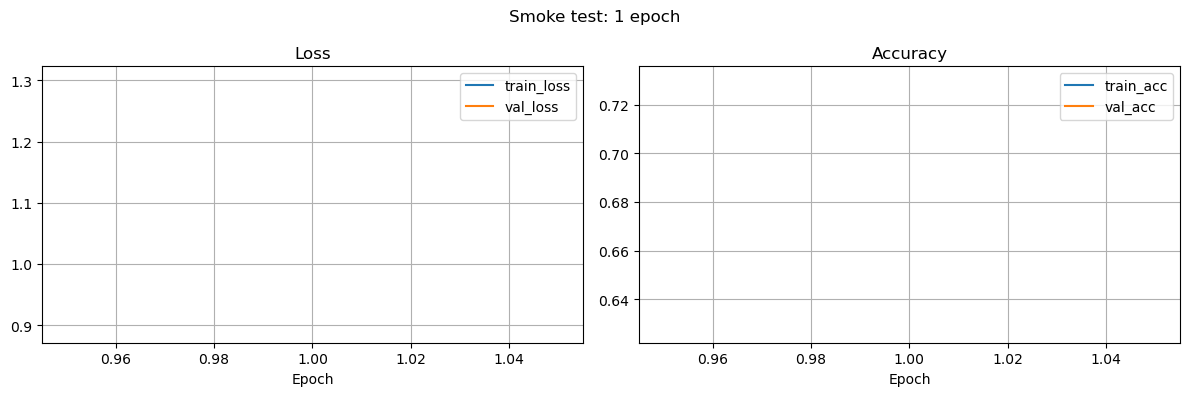

In [60]:
plot_history(smoke_history, title="Smoke test: 1 epoch")

## 6. Эксперименты (раздел 3 из задания)

Дальше идут обязательные эксперименты:

- Часть A (S08): E1-E4
  - E1: base
  - E2: Dropout
  - E3: BatchNorm
  - E4: EarlyStopping для лучшего из (E2/E3)

- Часть B (S09): O1-O3
  - O1: слишком большой learning rate
  - O2: слишком маленький learning rate
  - O3: SGD + momentum + weight decay

Все прогоны логируем в `artifacts/runs.csv`.
Лучшую модель из E4 сохраняем в `artifacts/best_model.pt`.

In [ ]:
from pathlib import Path
import copy
import time
import csv

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUNS_CSV_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_MODEL_PATH = ARTIFACTS_DIR / "best_model.pt"
BEST_CONFIG_PATH = ARTIFACTS_DIR / "best_config.json"

CURVES_BEST_PATH = FIGURES_DIR / "curves_best.png"
CURVES_LR_EXTREMES_PATH = FIGURES_DIR / "curves_lr_extremes.png"

print("Artifacts dir :", ARTIFACTS_DIR.resolve())
print("Figures dir   :", FIGURES_DIR.resolve())

Artifacts dir : C:\Users\anark\am-nom3\homeworks\HW08-09\homeworks\HW08-09\artifacts
Figures dir   : C:\Users\anark\am-nom3\homeworks\HW08-09\homeworks\HW08-09\artifacts\figures


In [62]:
class EarlyStopping:
    def __init__(self, patience=4, mode="max", min_delta=0.0):
        assert mode in {"max", "min"}
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.best_state_dict = None
        self.best_epoch = None
        self.counter = 0

    def step(self, score, model, epoch):
        improved = False

        if self.best_score is None:
            improved = True
        elif self.mode == "max" and score > self.best_score + self.min_delta:
            improved = True
        elif self.mode == "min" and score < self.best_score - self.min_delta:
            improved = True

        if improved:
            self.best_score = score
            self.best_state_dict = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


def model_summary_from_config(cfg):
    return (
        f"hidden_sizes={cfg['hidden_sizes']}, "
        f"activation={cfg['activation'].__name__}, "
        f"dropout={cfg['dropout']}, "
        f"use_batchnorm={cfg['use_batchnorm']}"
    )


def build_model_from_config(cfg):
    model = MLPClassifier(
        input_shape=input_shape,
        num_classes=num_classes,
        hidden_sizes=cfg["hidden_sizes"],
        activation=cfg["activation"],
        dropout=cfg["dropout"],
        use_batchnorm=cfg["use_batchnorm"],
    ).to(device)
    return model


def build_optimizer_from_config(model, cfg):
    optimizer_name = cfg["optimizer_name"].lower()

    if optimizer_name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg.get("weight_decay", 0.0),
        )

    if optimizer_name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=cfg["lr"],
            momentum=cfg.get("momentum", 0.0),
            weight_decay=cfg.get("weight_decay", 0.0),
        )

    raise ValueError(f"Unknown optimizer: {cfg['optimizer_name']}")


def save_history_plot(history, title=None, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss" if title is None else f"{title} — Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epochs, history["val_acc"], marker="o", label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy" if title is None else f"{title} — Accuracy")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


def append_run_to_csv(row, csv_path=RUNS_CSV_PATH):
    fieldnames = [
        "experiment_id",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "momentum",
        "weight_decay",
        "epochs_trained",
        "best_val_accuracy",
        "best_val_loss",
    ]

    file_exists = csv_path.exists()

    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)

In [74]:
def run_experiment(
    experiment_id,
    config,
    train_loader,
    val_loader,
    device,
    use_early_stopping=False,
    early_stopping_patience=4,
    verbose=True,
):
    set_seed(SEED)

    model = build_model_from_config(config)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer_from_config(model, config)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    early_stopper = None
    if use_early_stopping:
        early_stopper = EarlyStopping(
            patience=early_stopping_patience,
            mode="max",
            min_delta=0.0,
        )

    start_time = time.time()

    for epoch in range(1, config["epochs"] + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        train_loss, train_acc = train_metrics
        val_loss, val_acc = val_metrics

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(
                f"{experiment_id} | "
                f"Epoch {epoch:02d}/{config['epochs']} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        if use_early_stopping:
            should_stop = early_stopper.step(
                score=val_acc,
                model=model,
                epoch=epoch,
            )
            if should_stop:
                if verbose:
                    print(
                        f"Early stopping triggered at epoch {epoch}. "
                        f"Best epoch: {early_stopper.best_epoch}, "
                        f"best val_acc: {early_stopper.best_score:.4f}"
                    )
                break

    if use_early_stopping and early_stopper.best_state_dict is not None:
        model.load_state_dict(early_stopper.best_state_dict)

    elapsed = time.time() - start_time

    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["val_acc"])

    result = {
        "experiment_id": experiment_id,
        "config": config,
        "model": model,
        "criterion": criterion,
        "optimizer": optimizer,
        "history": history,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "elapsed_sec": elapsed,
    }

    append_run_to_csv(
        {
            "experiment_id": experiment_id,
            "dataset": data_config.dataset_name,
            "seed": SEED,
            "model_summary": model_summary_from_config(config),
            "optimizer": config["optimizer_name"],
            "lr": config["lr"],
            "momentum": config.get("momentum", 0.0),
            "weight_decay": config.get("weight_decay", 0.0),
            "epochs_trained": epochs_trained,
            "best_val_accuracy": best_val_acc,
            "best_val_loss": best_val_loss,
        }
    )

    return result

### 6.1. Часть A (S08): регуляризация и переобучение

Проводим 4 эксперимента:

- E1: базовая MLP без Dropout и BatchNorm
- E2: E1 + Dropout
- E3: E1 + BatchNorm
- E4: EarlyStopping для лучшего из E2/E3

In [75]:
base_hidden_sizes = (256, 128)

experiment_configs_A = {
    "E1": {
        "hidden_sizes": base_hidden_sizes,
        "activation": nn.ReLU,
        "dropout": 0.0,
        "use_batchnorm": False,
        "optimizer_name": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "epochs": 10,
    },
    "E2": {
        "hidden_sizes": base_hidden_sizes,
        "activation": nn.ReLU,
        "dropout": 0.3,
        "use_batchnorm": False,
        "optimizer_name": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "epochs": 10,
    },
    "E3": {
        "hidden_sizes": base_hidden_sizes,
        "activation": nn.ReLU,
        "dropout": 0.0,
        "use_batchnorm": True,
        "optimizer_name": "Adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "epochs": 10,
    },
}

experiment_results_A = {}
experiment_results_A

{}

In [76]:
for experiment_id in ["E1", "E2", "E3"]:
    print("=" * 90)
    print(experiment_id, experiment_configs_A[experiment_id])

    result = run_experiment(
        experiment_id=experiment_id,
        config=experiment_configs_A[experiment_id],
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        use_early_stopping=False,
        verbose=True,
    )

    experiment_results_A[experiment_id] = result

E1 {'hidden_sizes': (256, 128), 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'dropout': 0.0, 'use_batchnorm': False, 'optimizer_name': 'Adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 10}
E1 | Epoch 01/10 | train_loss=1.3023 | train_acc=0.6273 | val_loss=0.8918 | val_acc=0.7305
E1 | Epoch 02/10 | train_loss=0.7297 | train_acc=0.7707 | val_loss=0.6850 | val_acc=0.7842
E1 | Epoch 03/10 | train_loss=0.5981 | train_acc=0.8061 | val_loss=0.6002 | val_acc=0.8058
E1 | Epoch 04/10 | train_loss=0.5328 | train_acc=0.8235 | val_loss=0.5634 | val_acc=0.8207
E1 | Epoch 05/10 | train_loss=0.4925 | train_acc=0.8348 | val_loss=0.5374 | val_acc=0.8258
E1 | Epoch 06/10 | train_loss=0.4606 | train_acc=0.8423 | val_loss=0.5277 | val_acc=0.8274
E1 | Epoch 07/10 | train_loss=0.4371 | train_acc=0.8483 | val_loss=0.5175 | val_acc=0.8299
E1 | Epoch 08/10 | train_loss=0.4155 | train_acc=0.8535 | val_loss=0.5176 | val_acc=0.8316
E1 | Epoch 09/10 | train_loss=0.3950 | train_acc=0.8590 | val_loss=0

In [77]:
for experiment_id in ["E1", "E2", "E3"]:
    result = experiment_results_A[experiment_id]
    print(
        f"{experiment_id} | "
        f"epochs={result['epochs_trained']} | "
        f"best_val_acc={result['best_val_accuracy']:.4f} | "
        f"best_val_loss={result['best_val_loss']:.4f}"
    )

E1 | epochs=10 | best_val_acc=0.8329 | best_val_loss=0.5175
E2 | epochs=10 | best_val_acc=0.8190 | best_val_loss=0.5514
E3 | epochs=10 | best_val_acc=0.8482 | best_val_loss=0.4616



E1


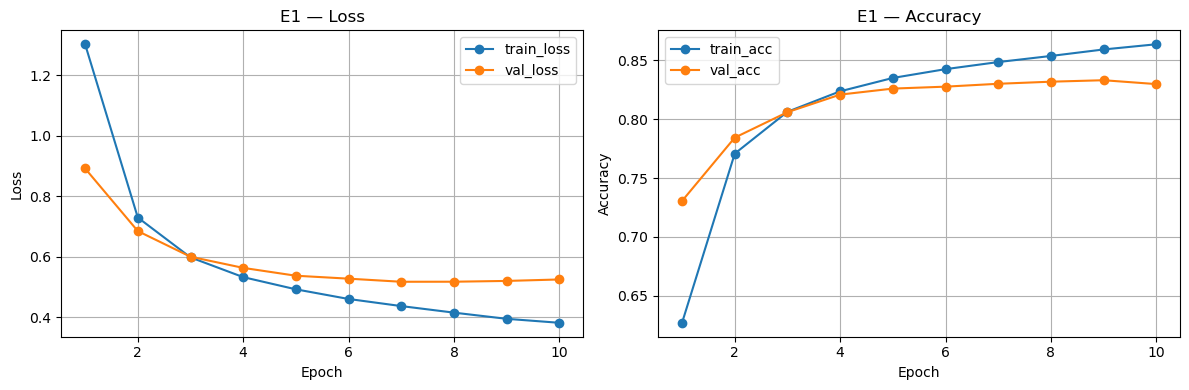


E2


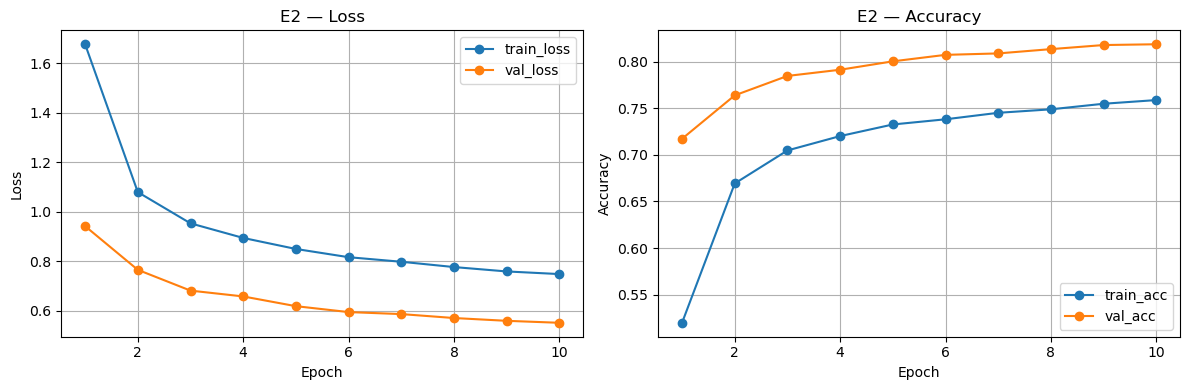


E3


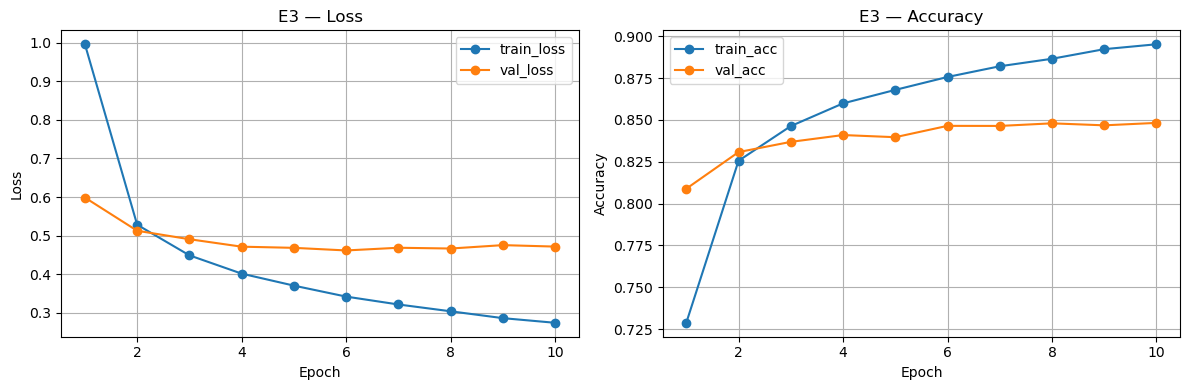

In [78]:
for experiment_id in ["E1", "E2", "E3"]:
    print(f"\n{experiment_id}")
    save_history_plot(
        history=experiment_results_A[experiment_id]["history"],
        title=experiment_id,
        save_path=None,
    )

In [79]:
candidate_ids = ["E2", "E3"]
best_candidate_id = max(
    candidate_ids,
    key=lambda exp_id: experiment_results_A[exp_id]["best_val_accuracy"]
)

print("Best candidate for E4:", best_candidate_id)

best_candidate_config = copy.deepcopy(experiment_configs_A[best_candidate_id])
best_candidate_config["epochs"] = 20

result_E4 = run_experiment(
    experiment_id="E4",
    config=best_candidate_config,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    use_early_stopping=True,
    early_stopping_patience=4,
    verbose=True,
)

experiment_results_A["E4"] = result_E4

Best candidate for E4: E3
E4 | Epoch 01/20 | train_loss=0.9957 | train_acc=0.7287 | val_loss=0.5985 | val_acc=0.8089
E4 | Epoch 02/20 | train_loss=0.5282 | train_acc=0.8256 | val_loss=0.5126 | val_acc=0.8308
E4 | Epoch 03/20 | train_loss=0.4489 | train_acc=0.8463 | val_loss=0.4907 | val_acc=0.8369
E4 | Epoch 04/20 | train_loss=0.4015 | train_acc=0.8599 | val_loss=0.4713 | val_acc=0.8410
E4 | Epoch 05/20 | train_loss=0.3704 | train_acc=0.8680 | val_loss=0.4683 | val_acc=0.8397
E4 | Epoch 06/20 | train_loss=0.3420 | train_acc=0.8757 | val_loss=0.4616 | val_acc=0.8465
E4 | Epoch 07/20 | train_loss=0.3216 | train_acc=0.8821 | val_loss=0.4686 | val_acc=0.8464
E4 | Epoch 08/20 | train_loss=0.3040 | train_acc=0.8866 | val_loss=0.4666 | val_acc=0.8480
E4 | Epoch 09/20 | train_loss=0.2862 | train_acc=0.8923 | val_loss=0.4753 | val_acc=0.8468
E4 | Epoch 10/20 | train_loss=0.2742 | train_acc=0.8952 | val_loss=0.4716 | val_acc=0.8482
E4 | Epoch 11/20 | train_loss=0.2609 | train_acc=0.8998 | val_lo

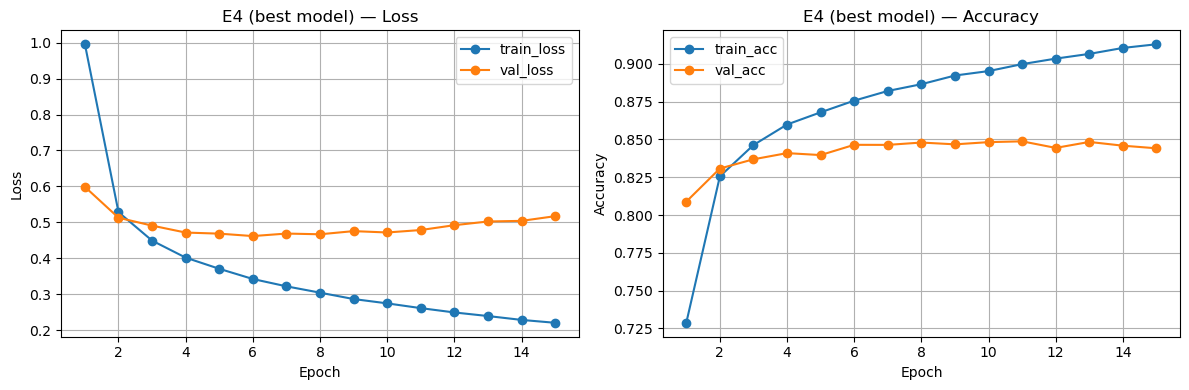

Saved model  : C:\Users\anark\am-nom3\homeworks\HW08-09\homeworks\HW08-09\artifacts\best_model.pt
Saved config : C:\Users\anark\am-nom3\homeworks\HW08-09\homeworks\HW08-09\artifacts\best_config.json
Saved figure : C:\Users\anark\am-nom3\homeworks\HW08-09\homeworks\HW08-09\artifacts\figures\curves_best.png


In [80]:
torch.save(result_E4["model"].state_dict(), BEST_MODEL_PATH)

best_config_to_save = {
    "experiment_id": "E4",
    "dataset": data_config.dataset_name,
    "seed": SEED,
    "input_shape": list(input_shape),
    "num_classes": int(num_classes),
    "hidden_sizes": list(best_candidate_config["hidden_sizes"]),
    "activation": best_candidate_config["activation"].__name__,
    "dropout": float(best_candidate_config["dropout"]),
    "use_batchnorm": bool(best_candidate_config["use_batchnorm"]),
    "optimizer_name": best_candidate_config["optimizer_name"],
    "lr": float(best_candidate_config["lr"]),
    "weight_decay": float(best_candidate_config.get("weight_decay", 0.0)),
    "epochs_max": int(best_candidate_config["epochs"]),
    "early_stopping_patience": 4,
}

with open(BEST_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_config_to_save, f, ensure_ascii=False, indent=2)

save_history_plot(
    history=result_E4["history"],
    title="E4 (best model)",
    save_path=CURVES_BEST_PATH,
)

print("Saved model  :", BEST_MODEL_PATH.resolve())
print("Saved config :", BEST_CONFIG_PATH.resolve())
print("Saved figure :", CURVES_BEST_PATH.resolve())

### 6.2. Часть B (S09): LR, оптимизаторы, weight decay

Используем ту же архитектуру, что и в E4.
Делаем 3 эксперимента:

- O1: слишком большой LR
- O2: слишком маленький LR
- O3: SGD + momentum + weight decay

In [81]:
fixed_architecture_config = {
    "hidden_sizes": tuple(best_candidate_config["hidden_sizes"]),
    "activation": best_candidate_config["activation"],
    "dropout": best_candidate_config["dropout"],
    "use_batchnorm": best_candidate_config["use_batchnorm"],
}

experiment_configs_B = {
    "O1": {
        **fixed_architecture_config,
        "optimizer_name": "Adam",
        "lr": 1e-1,
        "weight_decay": 0.0,
        "epochs": 6,
    },
    "O2": {
        **fixed_architecture_config,
        "optimizer_name": "Adam",
        "lr": 1e-5,
        "weight_decay": 0.0,
        "epochs": 6,
    },
    "O3": {
        **fixed_architecture_config,
        "optimizer_name": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs": 12,
    },
}

experiment_results_B = {}
experiment_results_B

{}

In [82]:
for experiment_id in ["O1", "O2", "O3"]:
    print("=" * 90)
    print(experiment_id, experiment_configs_B[experiment_id])

    result = run_experiment(
        experiment_id=experiment_id,
        config=experiment_configs_B[experiment_id],
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        use_early_stopping=False,
        verbose=True,
    )

    experiment_results_B[experiment_id] = result

O1 {'hidden_sizes': (256, 128), 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'dropout': 0.0, 'use_batchnorm': True, 'optimizer_name': 'Adam', 'lr': 0.1, 'weight_decay': 0.0, 'epochs': 6}
O1 | Epoch 01/6 | train_loss=1.0921 | train_acc=0.6697 | val_loss=0.8404 | val_acc=0.7289
O1 | Epoch 02/6 | train_loss=0.7684 | train_acc=0.7548 | val_loss=0.7266 | val_acc=0.7720
O1 | Epoch 03/6 | train_loss=0.7057 | train_acc=0.7725 | val_loss=0.7022 | val_acc=0.7775
O1 | Epoch 04/6 | train_loss=0.6616 | train_acc=0.7845 | val_loss=0.6575 | val_acc=0.7970
O1 | Epoch 05/6 | train_loss=0.6261 | train_acc=0.7950 | val_loss=0.6594 | val_acc=0.7880
O1 | Epoch 06/6 | train_loss=0.6097 | train_acc=0.7991 | val_loss=0.6014 | val_acc=0.8062
O2 {'hidden_sizes': (256, 128), 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'dropout': 0.0, 'use_batchnorm': True, 'optimizer_name': 'Adam', 'lr': 1e-05, 'weight_decay': 0.0, 'epochs': 6}
O2 | Epoch 01/6 | train_loss=3.4800 | train_acc=0.1641 | v

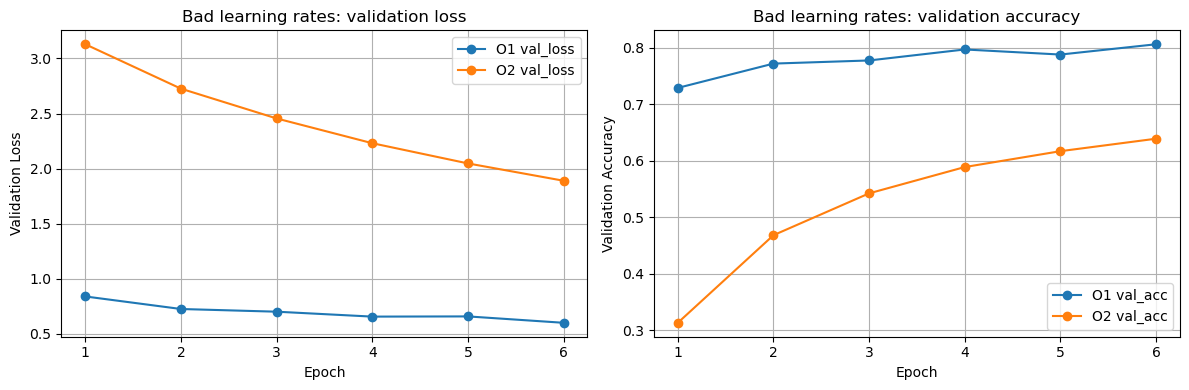

Saved figure : C:\Users\anark\am-nom3\homeworks\HW08-09\homeworks\HW08-09\artifacts\figures\curves_lr_extremes.png


In [83]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for experiment_id in ["O1", "O2"]:
    history = experiment_results_B[experiment_id]["history"]
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.plot(epochs, history["val_loss"], marker="o", label=f"{experiment_id} val_loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Bad learning rates: validation loss")
plt.legend()

plt.subplot(1, 2, 2)
for experiment_id in ["O1", "O2"]:
    history = experiment_results_B[experiment_id]["history"]
    epochs = range(1, len(history["val_acc"]) + 1)
    plt.plot(epochs, history["val_acc"], marker="o", label=f"{experiment_id} val_acc")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Bad learning rates: validation accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(CURVES_LR_EXTREMES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure :", CURVES_LR_EXTREMES_PATH.resolve())

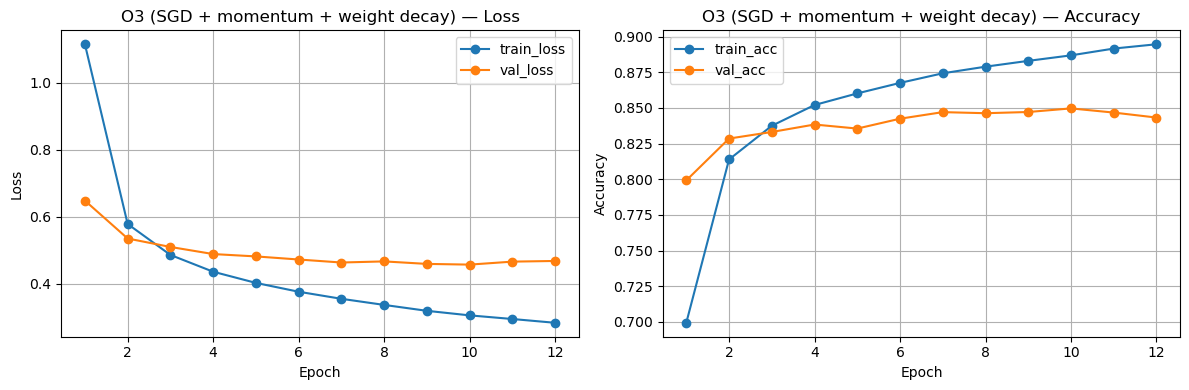

In [84]:
save_history_plot(
    history=experiment_results_B["O3"]["history"],
    title="O3 (SGD + momentum + weight decay)",
    save_path=None,
)

### 6.3. Финальная оценка на test

По условию test используем один раз: только для лучшей модели домашки, то есть E4.

In [86]:
best_model = build_model_from_config(best_candidate_config)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
best_model = best_model.to(device)

test_metrics = evaluate(
    model=best_model,
    dataloader=test_loader,
    criterion=nn.CrossEntropyLoss(),
    device=device,
)

print("Final test metrics for E4:")
print(test_metrics)

Final test metrics for E4:
(0.49547922771027747, 0.8448404255319149)


In [87]:
print("=== Part A ===")
for experiment_id in ["E1", "E2", "E3", "E4"]:
    result = experiment_results_A[experiment_id]
    print(
        f"{experiment_id} | "
        f"best_val_acc={result['best_val_accuracy']:.4f} | "
        f"best_val_loss={result['best_val_loss']:.4f} | "
        f"epochs_trained={result['epochs_trained']}"
    )

print("\n=== Part B ===")
for experiment_id in ["O1", "O2", "O3"]:
    result = experiment_results_B[experiment_id]
    print(
        f"{experiment_id} | "
        f"best_val_acc={result['best_val_accuracy']:.4f} | "
        f"best_val_loss={result['best_val_loss']:.4f} | "
        f"epochs_trained={result['epochs_trained']}"
    )

print("\n=== Final ===")
print("Best candidate before E4 :", best_candidate_id)
print("Best model saved to      :", BEST_MODEL_PATH)
print("Best config saved to     :", BEST_CONFIG_PATH)
print("Best curves saved to     :", CURVES_BEST_PATH)
print("LR extremes saved to     :", CURVES_LR_EXTREMES_PATH)
print("Final test metrics       :", test_metrics)

=== Part A ===
E1 | best_val_acc=0.8329 | best_val_loss=0.5175 | epochs_trained=10
E2 | best_val_acc=0.8190 | best_val_loss=0.5514 | epochs_trained=10
E3 | best_val_acc=0.8482 | best_val_loss=0.4616 | epochs_trained=10
E4 | best_val_acc=0.8488 | best_val_loss=0.4616 | epochs_trained=15

=== Part B ===
O1 | best_val_acc=0.8062 | best_val_loss=0.6014 | epochs_trained=6
O2 | best_val_acc=0.6391 | best_val_loss=1.8903 | epochs_trained=6
O3 | best_val_acc=0.8496 | best_val_loss=0.4578 | epochs_trained=12

=== Final ===
Best candidate before E4 : E3
Best model saved to      : homeworks\HW08-09\artifacts\best_model.pt
Best config saved to     : homeworks\HW08-09\artifacts\best_config.json
Best curves saved to     : homeworks\HW08-09\artifacts\figures\curves_best.png
LR extremes saved to     : homeworks\HW08-09\artifacts\figures\curves_lr_extremes.png
Final test metrics       : (0.49547922771027747, 0.8448404255319149)


In [88]:
with open(RUNS_CSV_PATH, "r", encoding="utf-8") as f:
    print(f.read())

experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
E1,EMNIST,42,"hidden_sizes=(256, 128), activation=ReLU, dropout=0.0, use_batchnorm=False",Adam,0.001,0.0,0.0,10,0.8328900709219859,0.5174911085595476
E2,EMNIST,42,"hidden_sizes=(256, 128), activation=ReLU, dropout=0.3, use_batchnorm=False",Adam,0.001,0.0,0.0,10,0.8189716312056737,0.5513852899801647
E3,EMNIST,42,"hidden_sizes=(256, 128), activation=ReLU, dropout=0.0, use_batchnorm=True",Adam,0.001,0.0,0.0,10,0.8482269503546099,0.46155797877210253
E4,EMNIST,42,"hidden_sizes=(256, 128), activation=ReLU, dropout=0.0, use_batchnorm=True",Adam,0.001,0.0,0.0,15,0.848758865248227,0.46155797877210253
O1,EMNIST,42,"hidden_sizes=(256, 128), activation=ReLU, dropout=0.0, use_batchnorm=True",Adam,0.1,0.0,0.0,6,0.8062056737588652,0.6014354727792401
O2,EMNIST,42,"hidden_sizes=(256, 128), activation=ReLU, dropout=0.0, use_batchnorm=True",Adam,1e-05,0.0,0.0,6,0.6390514184397164,1.8